<a href="https://colab.research.google.com/github/springboardmentor1234r/B13-AirFly-Insights-Internship/blob/nikhil_adduri_branch/Milestone%203%3A%20Route%2C%20Cancellation%2C%20and%20Seasonal%20Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Milestone 1 – Week 1: Data Foundation and Cleaning**                         
**Dataset: Flight Delay & Cancellation (2019–2023)**

**STEP 1: Mount Google Drive**

**STEP 1: Import Required Libraries**

In [ ]:
# Step 1: Install & Import Libraries
!pip install plotly --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [ ]:
# checking  installaion

import plotly
print("Plotly installed successfully")

Plotly installed successfully


**STEP 2: Create Project Folder Structure**

---



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**STEP 3: Load Dataset**

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/AirFly_Insights_Data_Set.csv', on_bad_lines='skip')

print(f"DataFrame shape: {df.shape}")
print("First 5 rows of the DataFrame:")
display(df.head())

DataFrame shape: (3000000, 32)
First 5 rows of the DataFrame:


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,19.0,1210.0,1443.0,4.0,1501,1447.0,-14.0,0.0,NaN,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.0,-6.0,9.0,2123.0,2232.0,38.0,2315,2310.0,-5.0,0.0,NaN,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.0,6.0,20.0,1020.0,1247.0,5.0,1252,1252.0,0.0,0.0,NaN,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608.0,-1.0,27.0,1635.0,1844.0,9.0,1829,1853.0,24.0,0.0,NaN,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,15.0,1853.0,2026.0,14.0,2041,2040.0,-1.0,0.0,NaN,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


**DATASET UNDERSTANDING**

**STEP 4: Check Dataset Size**

The dataset contains ___ rows and ___ columns representing airline operational records.

In [ ]:
df.shape

(3000000, 32)

**STEP 5: Check Column Names**

In [ ]:
df.columns


Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')

**SCHEMA ANALYSIS**

**STEP 6: Check Data Types**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

object → categorical

int/float → numerical

object but looks like date → needs conversion

**STEP 7: Separate Column Types**

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'ORIGIN',
       'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CANCELLATION_CODE'],
      dtype='object')

Numerical Columns:
Index(['DOT_CODE', 'FL_NUMBER', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY',
       'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME',
       'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')


**STEP 8: Create Feature Dictionary**

In [ ]:
feature_dictionary = pd.DataFrame({
    "Column_Name": df.columns,
    "Data_Type": df.dtypes.values,
    "Null_Count": df.isnull().sum().values
})

feature_dictionary

,Column_Name,Data_Type,Null_Count
0,FL_DATE,object,0
1,AIRLINE,object,0
2,AIRLINE_DOT,object,0
3,AIRLINE_CODE,object,0
4,DOT_CODE,int64,0
5,FL_NUMBER,int64,0
6,ORIGIN,object,0
7,ORIGIN_CITY,object,0
8,DEST,object,0
9,DEST_CITY,object,0


In [ ]:
import os

# Create the directory if it does not exist
os.makedirs("AirFly_Insights/reports", exist_ok=True)

feature_dictionary.to_csv("AirFly_Insights/reports/feature_dictionary.csv", index=False)

It documents:

Column name

Data type

Missing values

**MISSING VALUE STUDY**

**STEP 9: Check Null Counts**

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
CANCELLATION_CODE,2920860
DELAY_DUE_LATE_AIRCRAFT,2466137
DELAY_DUE_CARRIER,2466137
DELAY_DUE_SECURITY,2466137
DELAY_DUE_NAS,2466137
DELAY_DUE_WEATHER,2466137
ARR_DELAY,86198
ELAPSED_TIME,86198
AIR_TIME,86198
WHEELS_ON,79944


**STEP 10: Calculate Null Percentage**

In [ ]:
null_percentage = (df.isnull().sum() / len(df)) * 100
null_percentage = null_percentage.sort_values(ascending=False)

null_percentage

,0
CANCELLATION_CODE,97.362000
DELAY_DUE_LATE_AIRCRAFT,82.204567
DELAY_DUE_CARRIER,82.204567
DELAY_DUE_SECURITY,82.204567
DELAY_DUE_NAS,82.204567
DELAY_DUE_WEATHER,82.204567
ARR_DELAY,2.873267
ELAPSED_TIME,2.873267
AIR_TIME,2.873267
WHEELS_ON,2.664800


**STEP 11: Create Null Analysis Report**

In [ ]:
null_report = pd.DataFrame({
    "Null_Count": df.isnull().sum(),
    "Null_Percentage": (df.isnull().sum() / len(df)) * 100
})

null_report = null_report.sort_values(by="Null_Percentage", ascending=False)

null_report

,Null_Count,Null_Percentage
CANCELLATION_CODE,2920860,97.362000
DELAY_DUE_LATE_AIRCRAFT,2466137,82.204567
DELAY_DUE_CARRIER,2466137,82.204567
DELAY_DUE_SECURITY,2466137,82.204567
DELAY_DUE_NAS,2466137,82.204567
DELAY_DUE_WEATHER,2466137,82.204567
ARR_DELAY,86198,2.873267
ELAPSED_TIME,86198,2.873267
AIR_TIME,86198,2.873267
WHEELS_ON,79944,2.664800


In [ ]:
null_report.to_csv("AirFly_Insights/reports/null_analysis_report.csv")

**SAMPLING & OPTIMIZATION**

**STEP 12: Check Memory Usage**

In [ ]:
df.memory_usage(deep=True).sum() / (1024**2)

np.float64(1990.9640283584595)

**STEP 13: Optimize Memory (Convert Object → Category)**

In [ ]:
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [ ]:
df.memory_usage(deep=True).sum() / (1024**2)

np.float64(566.7607955932617)

**STEP 14: Create Sample Dataset (10%)**

In [ ]:
sample_df = df.sample(frac=0.1, random_state=42)
sample_df.shape

(300000, 32)

In [ ]:
import os

# Create the directory if it does not exist
os.makedirs("AirFly_Insights/data/sample", exist_ok=True)

sample_df.to_csv("AirFly_Insights/data/sample/sample_dataset.csv", index=False)

In [ ]:
df.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,2.920058e+06,2.913802e+06,3.000000e+06,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,1.466511e+03,4.260858e+00,2.638000e-02,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,5.318383e+02,5.117482e+01,1.602626e-01,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.600000e+01,0.000000e+00,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,1.053000e+03,-1.600000e+01,0.000000e+00,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,1.505000e+03,-7.000000e+00,0.000000e+00,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,1.913000e+03,7.000000e+00,0.000000e+00,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,2.400000e+03,2.934000e+03,1.000000e+00,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000


In [ ]:
null_report = df.isnull().sum().sort_values(ascending=False)
null_report

,0
CANCELLATION_CODE,2920860
DELAY_DUE_LATE_AIRCRAFT,2466137
DELAY_DUE_CARRIER,2466137
DELAY_DUE_SECURITY,2466137
DELAY_DUE_NAS,2466137
DELAY_DUE_WEATHER,2466137
ARR_DELAY,86198
ELAPSED_TIME,86198
AIR_TIME,86198
WHEELS_ON,79944


In [ ]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent.sort_values(ascending=False)

,0
CANCELLATION_CODE,97.362000
DELAY_DUE_LATE_AIRCRAFT,82.204567
DELAY_DUE_CARRIER,82.204567
DELAY_DUE_SECURITY,82.204567
DELAY_DUE_NAS,82.204567
DELAY_DUE_WEATHER,82.204567
ARR_DELAY,2.873267
ELAPSED_TIME,2.873267
AIR_TIME,2.873267
WHEELS_ON,2.664800


In [ ]:
null_percent.to_csv("null_analysis_report.csv")


In [ ]:
df.isnull().sum().sort_values(ascending=False)
(df.isnull().sum()/len(df)) * 100

,0
FL_DATE,0.000000
AIRLINE,0.000000
AIRLINE_DOT,0.000000
AIRLINE_CODE,0.000000
DOT_CODE,0.000000
FL_NUMBER,0.000000
ORIGIN,0.000000
ORIGIN_CITY,0.000000
DEST,0.000000
DEST_CITY,0.000000


In [ ]:
df.duplicated().sum()
df=df.drop_duplicates()


In [ ]:
df.memory_usage(deep=True)

,0
Index,132
FL_DATE,6166624
AIRLINE,3001774
AIRLINE_DOT,3001846
AIRLINE_CODE,3001474
DOT_CODE,24000000
FL_NUMBER,24000000
ORIGIN,6028056
ORIGIN_CITY,6031717
DEST,6028056


In [ ]:
for col in df.select_dtypes(include='object').columns:
  df[col] = df[col].astype('category')

for col in df.select_dtypes(include=['int64']).columns:
  df[col]=pd.to_numeric(df[col],downcast='integer')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype   
---  ------                   -----   
 0   FL_DATE                  category
 1   AIRLINE                  category
 2   AIRLINE_DOT              category
 3   AIRLINE_CODE             category
 4   DOT_CODE                 int16   
 5   FL_NUMBER                int16   
 6   ORIGIN                   category
 7   ORIGIN_CITY              category
 8   DEST                     category
 9   DEST_CITY                category
 10  CRS_DEP_TIME             int16   
 11  DEP_TIME                 float64 
 12  DEP_DELAY                float64 
 13  TAXI_OUT                 float64 
 14  WHEELS_OFF               float64 
 15  WHEELS_ON                float64 
 16  TAXI_IN                  float64 
 17  CRS_ARR_TIME             int16   
 18  ARR_TIME                 float64 
 19  ARR_DELAY                float64 
 20  CANCELLED               

In [ ]:
sample_df = df.sample(frac=0.1, random_state=42)
sample_df.shape

(300000, 32)

**WEEK 2 – DATA CLEANING & FEATURE ENGINEERING**

Objective

Convert the raw airline dataset into a clean structured dataset ready for analysis.

**Delay Null Handling**

Many delay columns have missing values.
We replace them with 0, because if no delay was recorded → delay = 0.

**Step 1: Define Delay Columns**

In [ ]:
delay_columns = [
    'DEP_DELAY',
    'ARR_DELAY',
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT'
]

**Step 2: Fill Missing Values**

In [ ]:
for col in delay_columns:
    if col in df.columns:
        df[col] = df[col].fillna(0)

**Step 3: Verify Null Values Removed**

In [ ]:
df[delay_columns].isnull().sum()

,0
DEP_DELAY,0
ARR_DELAY,0
DELAY_DUE_CARRIER,0
DELAY_DUE_WEATHER,0
DELAY_DUE_NAS,0
DELAY_DUE_SECURITY,0
DELAY_DUE_LATE_AIRCRAFT,0


Cancellation Decoding

Cancellation codes are stored as A, B, C, D.
We convert them to readable labels.

**Step 1: Check Cancellation Codes**

In [ ]:
df['CANCELLATION_CODE'].value_counts()

,count
CANCELLATION_CODE,
B,28772
D,24417
A,19476
C,6475


**Step 2: Create Mapping**

In [ ]:
# Decode Cancellation Codes

cancel_map = {
    'A': 'Carrier',
    'B': 'Weather',
    'C': 'NAS',
    'D': 'Security'
}

df['CANCELLATION_REASON'] = df['CANCELLATION_CODE'].map(cancel_map)

df[['CANCELLATION_CODE','CANCELLATION_REASON']].head()

,CANCELLATION_CODE,CANCELLATION_REASON
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


**Step 3: Create New Column**

In [ ]:
df['CANCELLATION_REASON'] = df['CANCELLATION_CODE'].map(cancel_map)

**Step 4: Verify**

In [ ]:
df[['CANCELLATION_CODE','CANCELLATION_REASON']].head()

,CANCELLATION_CODE,CANCELLATION_REASON
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


## **Datetime Engineering**

Airline datasets contain date and time information.                                                         
We extract useful time features.

**Step 1: Convert Date Column**

In [ ]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

**Step 2: Extract Month**

In [ ]:
df['MONTH'] = df['FL_DATE'].dt.month

**Step 3: Extract Day Name**

In [ ]:
df['DAY_NAME'] = df['FL_DATE'].dt.day_name()

Extract Departure Hour

Scheduled departure time looks like:



1300 → 13:00




845 → 08:45

In [ ]:
df['DEP_HOUR'] = df['CRS_DEP_TIME'] // 100

**Verify**

In [ ]:
df[['FL_DATE','MONTH','DAY_NAME','DEP_HOUR']].head()

,FL_DATE,MONTH,DAY_NAME,DEP_HOUR
0,2019-01-09,1,Wednesday,11
1,2022-11-19,11,Saturday,21
2,2022-07-22,7,Friday,9
3,2023-03-06,3,Monday,16
4,2020-02-23,2,Sunday,18


**Route Engineering**

Flights travel between origin airport and destination airport.

We create a Route column.

**Step 1: Create Route Column**

In [ ]:
df['ROUTE'] = df['ORIGIN'].astype(str) + "-" + df['DEST'].astype(str)

In [ ]:
df[['ORIGIN','DEST','ROUTE']].head()

,ORIGIN,DEST,ROUTE
0,FLL,EWR,FLL-EWR
1,MSP,SEA,MSP-SEA
2,DEN,MSP,DEN-MSP
3,MSP,SFO,MSP-SFO
4,MCO,DFW,MCO-DFW


In [ ]:
# Create Delay Flag (15+ minutes)

df['IS_DELAYED'] = np.where(df['ARR_DELAY'] > 15, 1, 0)

df[['ARR_DELAY','IS_DELAYED']].head()

,ARR_DELAY,IS_DELAYED
0,-14.0,0
1,-5.0,0
2,0.0,0
3,24.0,1
4,-1.0,0


**Save Clean Dataset**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

**Step 2: Check Dataset Shape**

In [ ]:
df.shape

(3000000, 38)

**Step 3: Save Clean Dataset**

In [ ]:
df.to_csv("cleaned_airfly_dataset.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_airfly_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Pushing to GitHub: Milestone 1**

To manage your project versions and push to GitHub, we'll first organize your work into a 'Milestone 1' folder, then set up Git, commit your changes, and push them to a remote repository.

In [ ]:
import os

# Create a directory for Milestone 1 if it doesn't exist
output_dir = 'Milestone_1_Flight_Delay_Analysis'
os.makedirs(output_dir, exist_ok=True)

# Move the generated reports and cleaned dataset into the Milestone 1 folder
# Check if the files exist before moving to avoid errors

files_to_move = [
    'AirFly_Insights/reports/feature_dictionary.csv',
    'AirFly_Insights/reports/null_analysis_report.csv',
    'AirFly_Insights/data/sample/sample_dataset.csv',
    'cleaned_airfly_dataset.csv',
    'null_analysis_report.csv' # This was generated without a path, so it's in the root
]

for file_path in files_to_move:
    if os.path.exists(file_path):
        # Extract just the filename from the path
        filename = os.path.basename(file_path)
        # Construct the destination path within the output directory
        destination_path = os.path.join(output_dir, filename)
        os.rename(file_path, destination_path)
        print(f"Moved {file_path} to {destination_path}")
    else:
        print(f"File not found: {file_path}. Skipping move.")

print(f"Files organized into '{output_dir}' folder.")


File not found: AirFly_Insights/reports/feature_dictionary.csv. Skipping move.
File not found: AirFly_Insights/reports/null_analysis_report.csv. Skipping move.
File not found: AirFly_Insights/data/sample/sample_dataset.csv. Skipping move.
Moved cleaned_airfly_dataset.csv to Milestone_1_Flight_Delay_Analysis/cleaned_airfly_dataset.csv
Moved null_analysis_report.csv to Milestone_1_Flight_Delay_Analysis/null_analysis_report.csv
Files organized into 'Milestone_1_Flight_Delay_Analysis' folder.


In [ ]:
%cd /content/Milestone_1_Flight_Delay_Analysis

/content/Milestone_1_Flight_Delay_Analysis


In [ ]:
!git init

Reinitialized existing Git repository in /content/Milestone_1_Flight_Delay_Analysis/.git/


In [ ]:
!git add .

In [ ]:
!ls /content/Milestone_1_Flight_Delay_Analysis

 feature_dictionary.csv		     sample_dataset.csv
 Milestone_1_Flight_Delay_Analysis  'Untitled Folder'


In [ ]:
!ls /content/Milestone_1_Flight_Delay_Analysis

 feature_dictionary.csv		     sample_dataset.csv
 Milestone_1_Flight_Delay_Analysis  'Untitled Folder'


In [ ]:
!ls /content

AirFly_Insights  drive	Milestone_1_Flight_Delay_Analysis  sample_data


In [ ]:
!ls /content/Milestone_1_Flight_Delay_Analysis

 feature_dictionary.csv		     sample_dataset.csv
 Milestone_1_Flight_Delay_Analysis  'Untitled Folder'


In [ ]:
!zip -r Milestone_1.zip /content/Milestone_1_Flight_Delay_Analysis

  adding: content/Milestone_1_Flight_Delay_Analysis/ (stored 0%)
  adding: content/Milestone_1_Flight_Delay_Analysis/.git/ (stored 0%)
  adding: content/Milestone_1_Flight_Delay_Analysis/.git/refs/ (stored 0%)
  adding: content/Milestone_1_Flight_Delay_Analysis/.git/refs/heads/ (stored 0%)
  adding: content/Milestone_1_Flight_Delay_Analysis/.git/refs/heads/master (deflated 2%)
  adding: content/Milestone_1_Flight_Delay_Analysis/.git/refs/heads/nikhil_adduri_branch (deflated 2%)
  adding: content/Milestone_1_Flight_Delay_Analysis/.git/refs/tags/ (stored 0%)
  adding: content/Milestone_1_Flight_Delay_Analysis/.git/index (deflated 24%)
  adding: content/Milestone_1_Flight_Delay_Analysis/.git/info/ (stored 0%)
  adding: content/Milestone_1_Flight_Delay_Analysis/.git/info/exclude (deflated 28%)
  adding: content/Milestone_1_Flight_Delay_Analysis/.git/logs/ (stored 0%)
  adding: content/Milestone_1_Flight_Delay_Analysis/.git/logs/refs/ (stored 0%)
  adding: content/Milestone_1_Flight_Delay_A

In [ ]:
from google.colab import files
files.download('Milestone_1.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**WEEK 3 – Univariate & Bivariate Visual Analysis**

**STEP 1: Top Airlines (Flight Volume)**

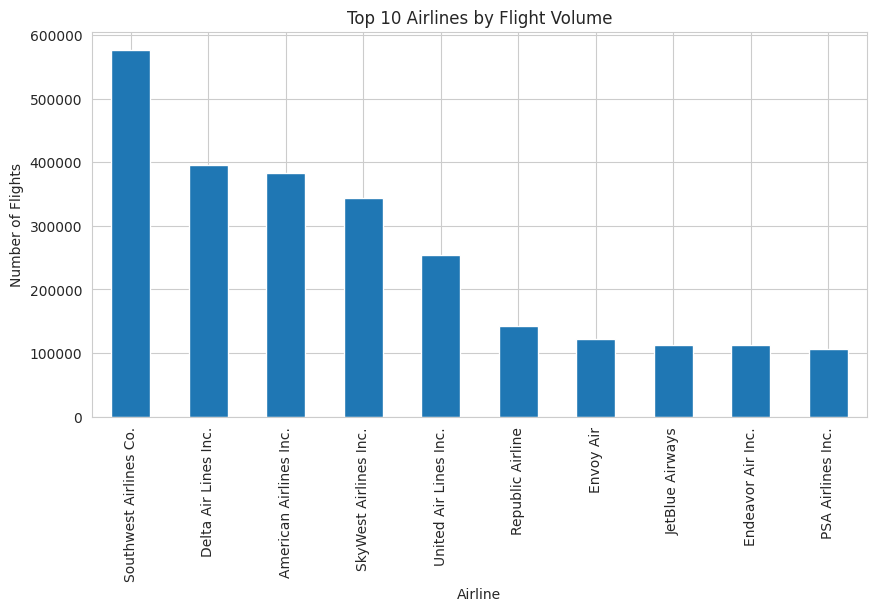

In [ ]:
plt.figure(figsize=(10,5))

df['AIRLINE'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Airlines by Flight Volume")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")

plt.show()

Few airlines dominate the total flights












Helps identify major players

**STEP 2: Top Routes**

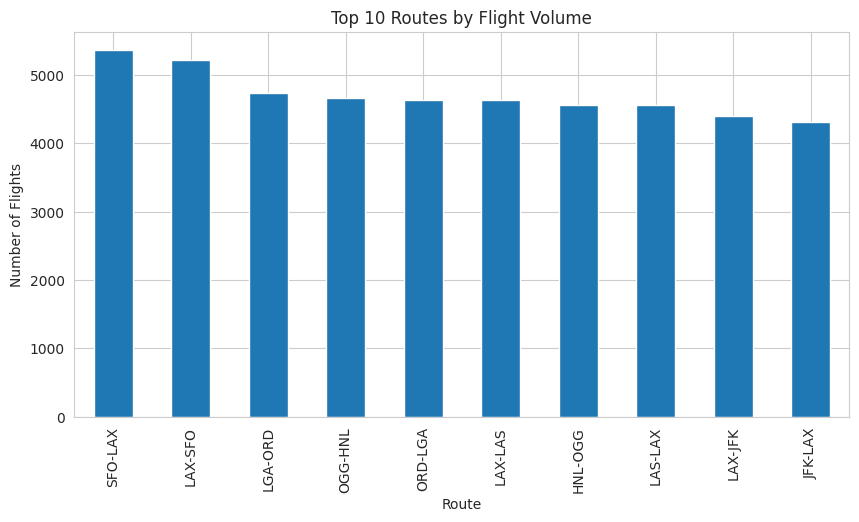

In [ ]:
plt.figure(figsize=(10,5))

df['ROUTE'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Routes by Flight Volume")
plt.xlabel("Route")
plt.ylabel("Number of Flights")

plt.show()

**STEP 3: Busiest Months**

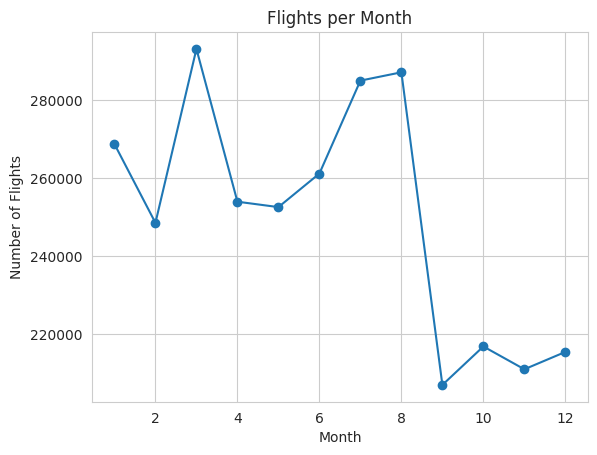

In [ ]:
monthly = df.groupby('MONTH').size()

plt.figure()

monthly.plot(kind='line', marker='o')

plt.title("Flights per Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")

plt.show()

**STEP 4: Flights by Day of Week**

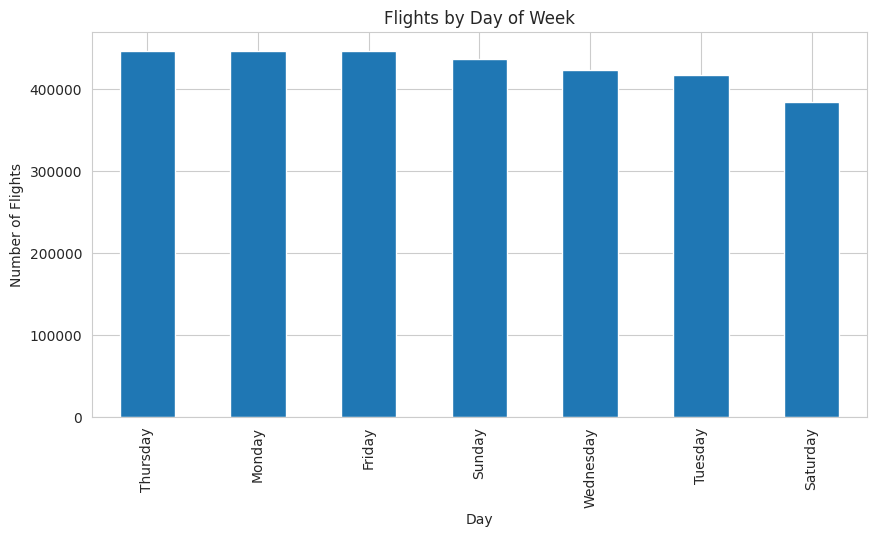

In [ ]:
plt.figure(figsize=(10,5))

df['DAY_NAME'].value_counts().plot(kind='bar')

plt.title("Flights by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Flights")

plt.show()

**STEP 5: Flight Distribution by Hour**

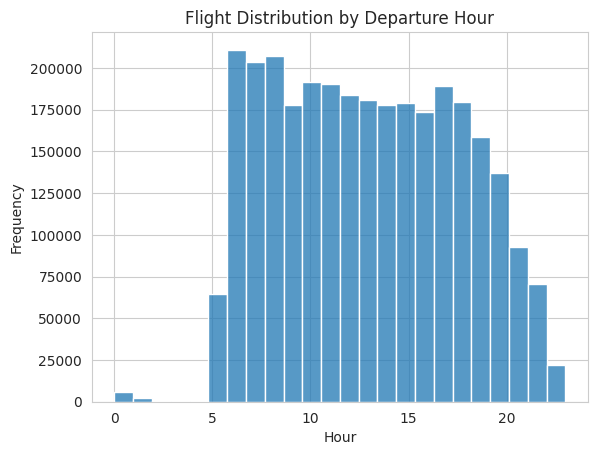

In [ ]:
plt.figure()

sns.histplot(df['DEP_HOUR'], bins=24)

plt.title("Flight Distribution by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Frequency")

plt.show()

**STEP 6: Busiest Airports**

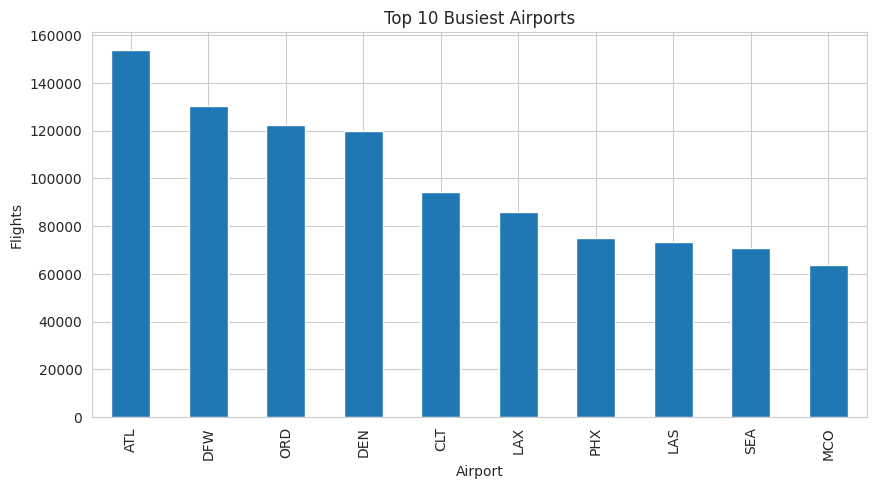

In [ ]:
plt.figure(figsize=(10,5))

df['ORIGIN'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Busiest Airports")
plt.xlabel("Airport")
plt.ylabel("Flights")

plt.show()

**STEP 7: Delay Distribution**

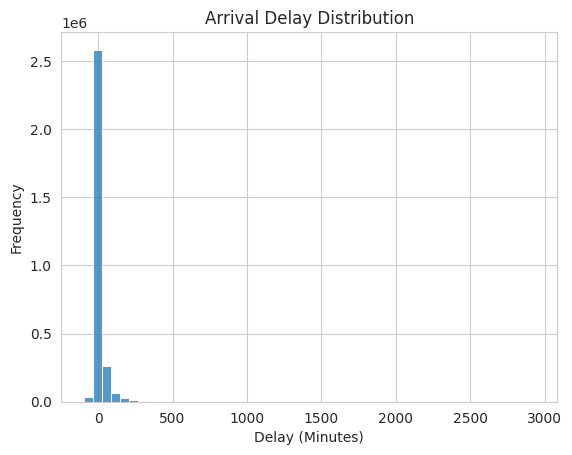

In [ ]:
plt.figure()

sns.histplot(df['ARR_DELAY'], bins=50)

plt.title("Arrival Delay Distribution")
plt.xlabel("Delay (Minutes)")
plt.ylabel("Frequency")

plt.show()

**STEP 8: Boxplot (Outliers)**

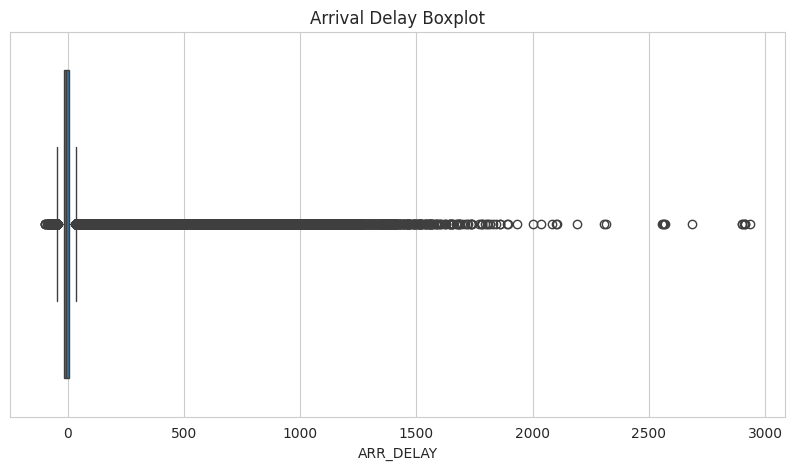

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['ARR_DELAY'])

plt.title("Arrival Delay Boxplot")

plt.show()

**STEP 9: Airline vs Average Delay (Bivariate)**

/tmp/ipykernel_12132/3654057673.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False).head(10).plot(kind='bar')


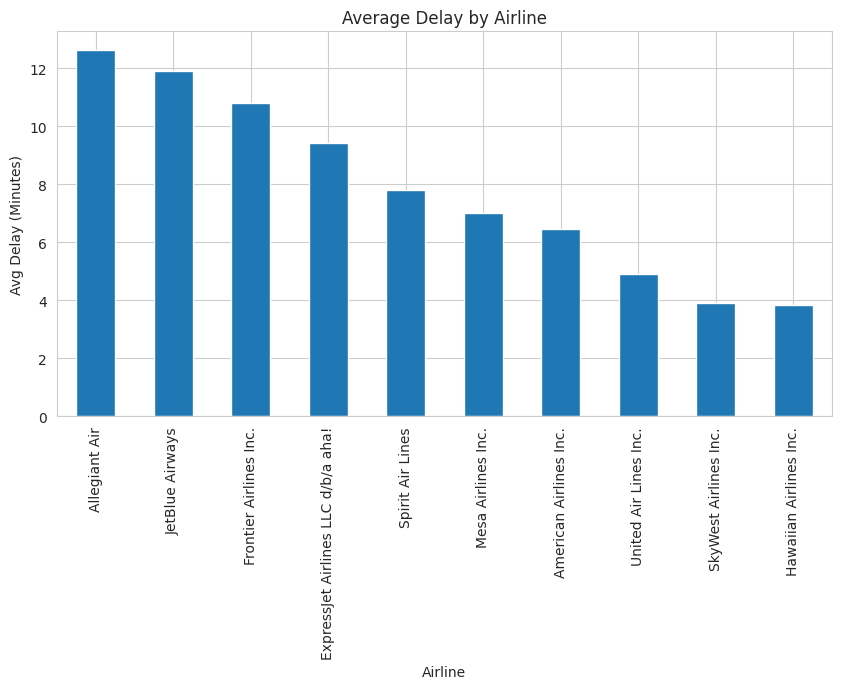

In [ ]:
plt.figure(figsize=(10,5))

df.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Average Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Avg Delay (Minutes)")

plt.show()

**WEEK 4 – Delay Analysis (Airline & Weather)**

**STEP 1: Total Delay by Cause**

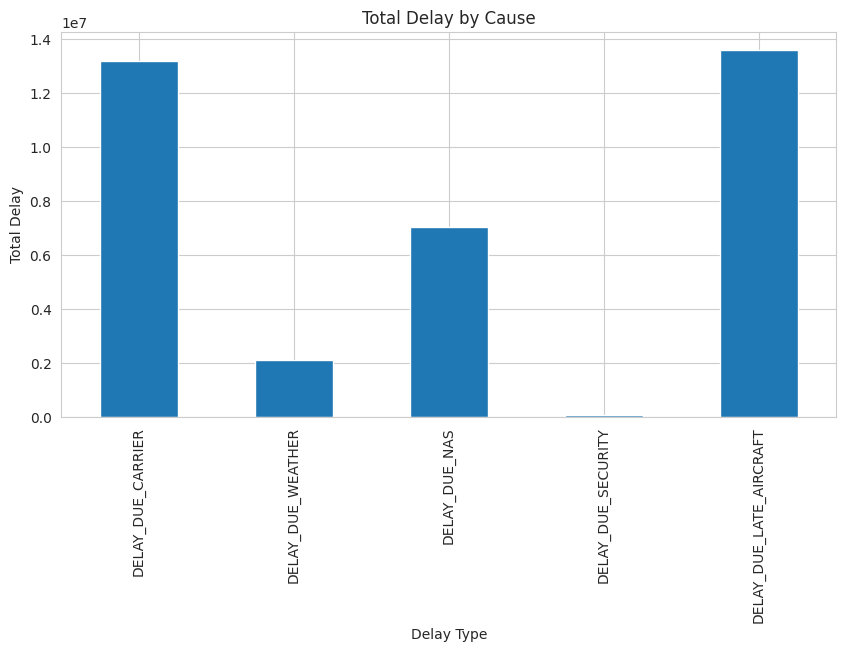

In [ ]:
delay_types = [
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT'
]

delay_sum = df[delay_types].sum()

plt.figure(figsize=(10,5))
delay_sum.plot(kind='bar')

plt.title("Total Delay by Cause")
plt.xlabel("Delay Type")
plt.ylabel("Total Delay")

plt.show()

**STEP 2: Carrier Delay by Airline**

/tmp/ipykernel_12132/1748354815.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AIRLINE')['DELAY_DUE_CARRIER'].mean().sort_values(ascending=False).head(10).plot(kind='bar')


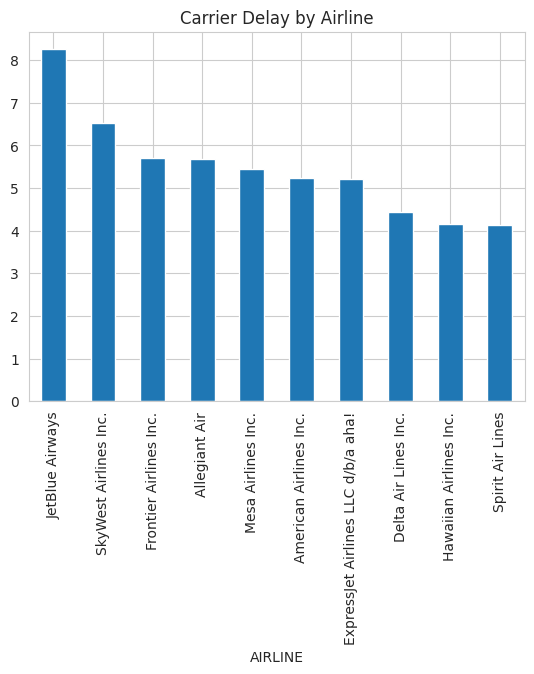

In [ ]:
df.groupby('AIRLINE')['DELAY_DUE_CARRIER'].mean().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Carrier Delay by Airline")
plt.show()

**STEP 3: Weather Delay by Airline**

/tmp/ipykernel_12132/2261164321.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AIRLINE')['DELAY_DUE_WEATHER'].mean().sort_values(ascending=False).head(10).plot(kind='bar')


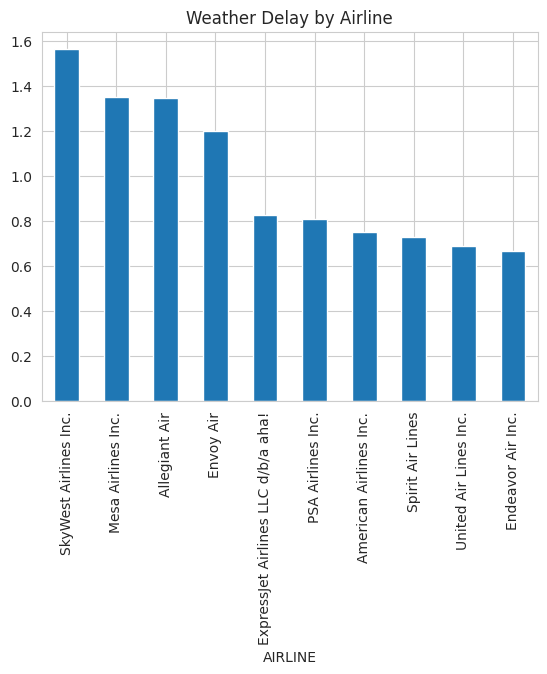

In [ ]:
df.groupby('AIRLINE')['DELAY_DUE_WEATHER'].mean().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Weather Delay by Airline")
plt.show()

**STEP 4: NAS Delay (Air Traffic System)**

/tmp/ipykernel_12132/1539465256.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AIRLINE')['DELAY_DUE_NAS'].mean().sort_values(ascending=False).plot(kind='bar')


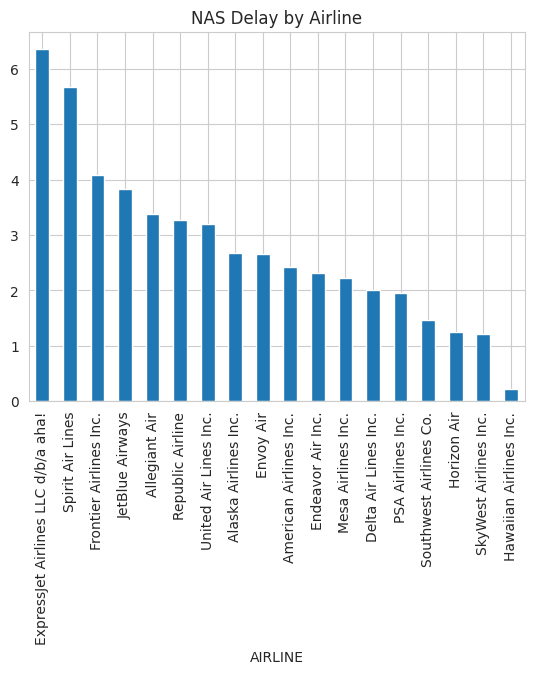

In [ ]:
df.groupby('AIRLINE')['DELAY_DUE_NAS'].mean().sort_values(ascending=False).plot(kind='bar')

plt.title("NAS Delay by Airline")
plt.show()

**STEP 5: Delay by Departure Hour**

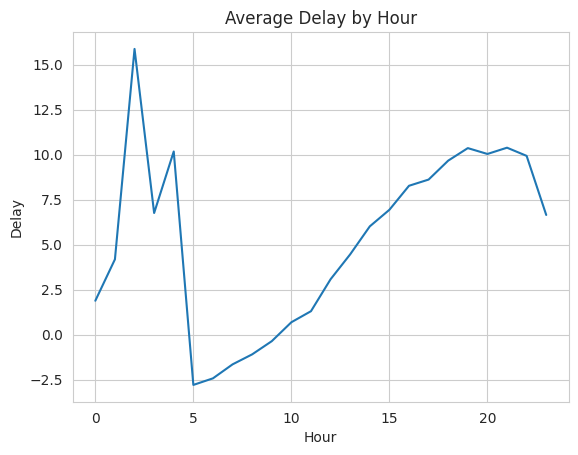

In [ ]:
hour_delay = df.groupby('DEP_HOUR')['ARR_DELAY'].mean()

plt.figure()
hour_delay.plot(kind='line')

plt.title("Average Delay by Hour")
plt.xlabel("Hour")
plt.ylabel("Delay")

plt.show()

**STEP 6: Delay by Airport**

/tmp/ipykernel_12132/3438445096.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10).plot(kind='bar')


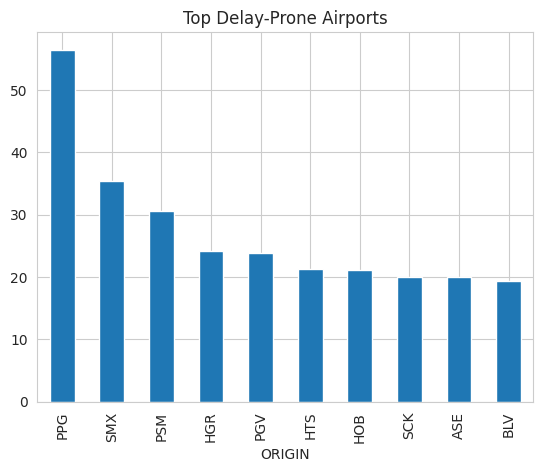

In [ ]:
df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top Delay-Prone Airports")
plt.show()

**STEP 7: Delay Percentage by Airline**

/tmp/ipykernel_12132/248804550.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_rate = df.groupby('AIRLINE')['IS_DELAYED'].mean() * 100


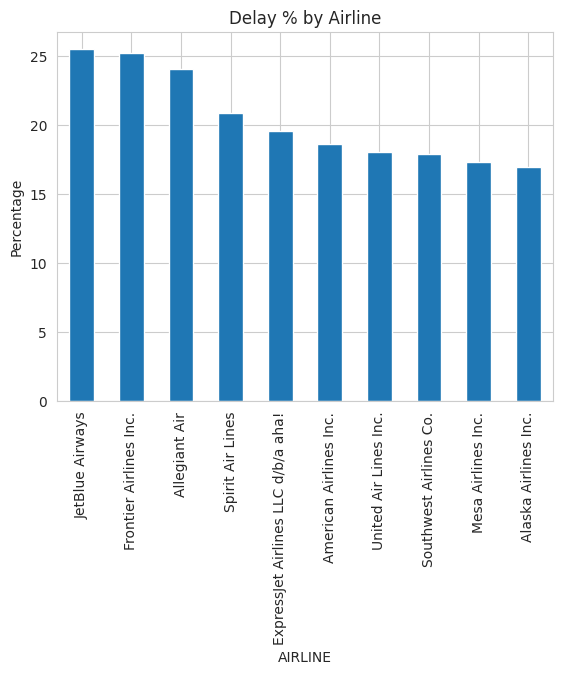

In [ ]:
delay_rate = df.groupby('AIRLINE')['IS_DELAYED'].mean() * 100

delay_rate.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Delay % by Airline")
plt.ylabel("Percentage")

plt.show()

**STEP 8: Delay Heatmap (Airport vs Delay)**

/tmp/ipykernel_12132/588408137.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = filtered_df.pivot_table(


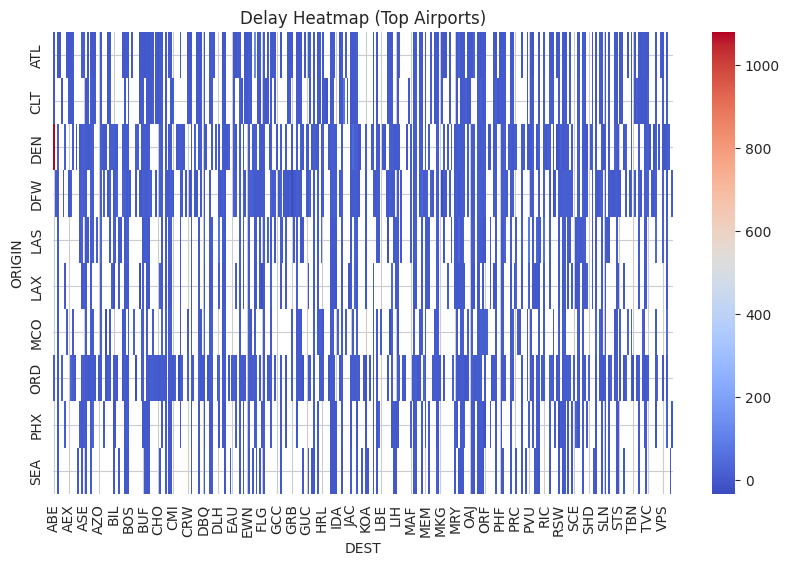

In [ ]:
top_airports = df['ORIGIN'].value_counts().head(10).index

filtered_df = df[df['ORIGIN'].isin(top_airports)]

pivot = filtered_df.pivot_table(
    values='ARR_DELAY',
    index='ORIGIN',
    columns='DEST',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='coolwarm')

plt.title("Delay Heatmap (Top Airports)")
plt.show()

## **Milestone 2 – Delay Analysis Visualizations**

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define output directory paths
milestone_2_output_dir = 'Milestone_2_Delay_Analysis_Visualizations'
week3_dir = os.path.join(milestone_2_output_dir, 'Week_3_Univariate_Bivariate_Plots')
week4_dir = os.path.join(milestone_2_output_dir, 'Week_4_Delay_Analysis_Plots')

# Create the directories if they don't exist
os.makedirs(week3_dir, exist_ok=True)
os.makedirs(week4_dir, exist_ok=True)

print(f"Created directories: '{week3_dir}' and '{week4_dir}'")
print("Generating and saving plots...")

Created directories: 'Milestone_2_Delay_Analysis_Visualizations/Week_3_Univariate_Bivariate_Plots' and 'Milestone_2_Delay_Analysis_Visualizations/Week_4_Delay_Analysis_Plots'
Generating and saving plots...


### Saving Week 3 Plots: Univariate & Bivariate Visual Analysis

In [ ]:
# STEP 1: Top Airlines (Flight Volume)
plt.figure(figsize=(10,5))
df['AIRLINE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Airlines by Flight Volume")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'top_10_airlines.png'))
plt.clf() # Clear the current figure

# STEP 2: Top Routes
plt.figure(figsize=(10,5))
df['ROUTE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Routes by Flight Volume")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'top_10_routes.png'))
plt.clf()

# STEP 3: Busiest Months
monthly = df.groupby('MONTH').size()
plt.figure()
monthly.plot(kind='line', marker='o')
plt.title("Flights per Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'flights_per_month.png'))
plt.clf()

# STEP 4: Flights by Day of Week
plt.figure(figsize=(10,5))
df['DAY_NAME'].value_counts().plot(kind='bar')
plt.title("Flights by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'flights_by_day_of_week.png'))
plt.clf()

# STEP 5: Flight Distribution by Hour
plt.figure()
sns.histplot(df['DEP_HOUR'], bins=24)
plt.title("Flight Distribution by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'flight_distribution_by_departure_hour.png'))
plt.clf()

# STEP 6: Busiest Airports
plt.figure(figsize=(10,5))
df['ORIGIN'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Busiest Airports")
plt.xlabel("Airport")
plt.ylabel("Flights")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'top_10_busiest_airports.png'))
plt.clf()

# STEP 7: Delay Distribution
plt.figure()
sns.histplot(df['ARR_DELAY'], bins=50)
plt.title("Arrival Delay Distribution")
plt.xlabel("Delay (Minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'arrival_delay_distribution.png'))
plt.clf()

# STEP 8: Boxplot (Outliers)
plt.figure(figsize=(10,5))
sns.boxplot(x=df['ARR_DELAY'])
plt.title("Arrival Delay Boxplot")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'arrival_delay_boxplot.png'))
plt.clf()

# STEP 9: Airline vs Average Delay (Bivariate)
plt.figure(figsize=(10,5))
df.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Average Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Avg Delay (Minutes)")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'avg_delay_by_airline.png'))
plt.clf()

print("Week 3 plots saved!")

/tmp/ipykernel_12132/2131957606.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False).head(10).plot(kind='bar')


Week 3 plots saved!


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [ ]:
# STEP 1: Top Airlines (Flight Volume)
plt.figure(figsize=(10,5))
df['AIRLINE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Airlines by Flight Volume")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'top_10_airlines.png'))
plt.clf() # Clear the current figure

# STEP 2: Top Routes
plt.figure(figsize=(10,5))
df['ROUTE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Routes by Flight Volume")
plt.xlabel("Route")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'top_10_routes.png'))
plt.clf()

# STEP 3: Busiest Months
monthly = df.groupby('MONTH').size()
plt.figure()
monthly.plot(kind='line', marker='o')
plt.title("Flights per Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'flights_per_month.png'))
plt.clf()

# STEP 4: Flights by Day of Week
plt.figure(figsize=(10,5))
df['DAY_NAME'].value_counts().plot(kind='bar')
plt.title("Flights by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'flights_by_day_of_week.png'))
plt.clf()

# STEP 5: Flight Distribution by Hour
plt.figure()
sns.histplot(df['DEP_HOUR'], bins=24)
plt.title("Flight Distribution by Departure Hour")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'flight_distribution_by_departure_hour.png'))
plt.clf()

# STEP 6: Busiest Airports
plt.figure(figsize=(10,5))
df['ORIGIN'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Busiest Airports")
plt.xlabel("Airport")
plt.ylabel("Flights")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'top_10_busiest_airports.png'))
plt.clf()

# STEP 7: Delay Distribution
plt.figure()
sns.histplot(df['ARR_DELAY'], bins=50)
plt.title("Arrival Delay Distribution")
plt.xlabel("Delay (Minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'arrival_delay_distribution.png'))
plt.clf()

# STEP 8: Boxplot (Outliers)
plt.figure(figsize=(10,5))
sns.boxplot(x=df['ARR_DELAY'])
plt.title("Arrival Delay Boxplot")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'arrival_delay_boxplot.png'))
plt.clf()

# STEP 9: Airline vs Average Delay (Bivariate)
plt.figure(figsize=(10,5))
df.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Average Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Avg Delay (Minutes)")
plt.tight_layout()
plt.savefig(os.path.join(week3_dir, 'avg_delay_by_airline.png'))
plt.clf()

print("Week 3 plots saved!")

/tmp/ipykernel_12132/2131957606.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False).head(10).plot(kind='bar')


Week 3 plots saved!


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [ ]:
# STEP 1: Total Delay by Cause
delay_types = [
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT'
]
delay_sum = df[delay_types].sum()
plt.figure(figsize=(10,5))
delay_sum.plot(kind='bar')
plt.title("Total Delay by Cause")
plt.xlabel("Delay Type")
plt.ylabel("Total Delay")
plt.tight_layout()
plt.savefig(os.path.join(week4_dir, 'total_delay_by_cause.png'))
plt.clf()

# STEP 2: Carrier Delay by Airline
plt.figure(figsize=(10,5))
df.groupby('AIRLINE')['DELAY_DUE_CARRIER'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Carrier Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Avg Carrier Delay (Minutes)")
plt.tight_layout()
plt.savefig(os.path.join(week4_dir, 'carrier_delay_by_airline.png'))
plt.clf()

# STEP 3: Weather Delay by Airline
plt.figure(figsize=(10,5))
df.groupby('AIRLINE')['DELAY_DUE_WEATHER'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Weather Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Avg Weather Delay (Minutes)")
plt.tight_layout()
plt.savefig(os.path.join(week4_dir, 'weather_delay_by_airline.png'))
plt.clf()

# STEP 4: NAS Delay (Air Traffic System)
plt.figure(figsize=(10,5))
df.groupby('AIRLINE')['DELAY_DUE_NAS'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("NAS Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Avg NAS Delay (Minutes)")
plt.tight_layout()
plt.savefig(os.path.join(week4_dir, 'nas_delay_by_airline.png'))
plt.clf()

# STEP 5: Delay by Departure Hour
hour_delay = df.groupby('DEP_HOUR')['ARR_DELAY'].mean()
plt.figure()
hour_delay.plot(kind='line')
plt.title("Average Delay by Hour")
plt.xlabel("Hour")
plt.ylabel("Delay (Minutes)")
plt.tight_layout()
plt.savefig(os.path.join(week4_dir, 'avg_delay_by_departure_hour.png'))
plt.clf()

# STEP 6: Delay by Airport
plt.figure(figsize=(10,5))
df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Delay-Prone Airports")
plt.xlabel("Airport")
plt.ylabel("Avg Delay (Minutes)")
plt.tight_layout()
plt.savefig(os.path.join(week4_dir, 'top_delay_prone_airports.png'))
plt.clf()

# STEP 7: Delay Percentage by Airline
delay_rate = df.groupby('AIRLINE')['IS_DELAYED'].mean() * 100
plt.figure(figsize=(10,5))
delay_rate.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Delay % by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay Percentage")
plt.tight_layout()
plt.savefig(os.path.join(week4_dir, 'delay_percentage_by_airline.png'))
plt.clf()

# STEP 8: Delay Heatmap (Airport vs Delay)
top_airports = df['ORIGIN'].value_counts().head(10).index
filtered_df = df[df['ORIGIN'].isin(top_airports)]
pivot = filtered_df.pivot_table(
    values='ARR_DELAY',
    index='ORIGIN',
    columns='DEST',
    aggfunc='mean'
)
plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='coolwarm', annot=True, fmt=".1f", linewidths=.5)
plt.title("Delay Heatmap (Top Airports)")
plt.tight_layout()
plt.savefig(os.path.join(week4_dir, 'delay_heatmap_top_airports.png'))
plt.clf()

print("Week 4 plots saved!")

/tmp/ipykernel_12132/1238035180.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AIRLINE')['DELAY_DUE_CARRIER'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
/tmp/ipykernel_12132/1238035180.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AIRLINE')['DELAY_DUE_WEATHER'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
/tmp/ipykernel_12132/1238035180.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fu

Week 4 plots saved!


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [ ]:
# Zip the Milestone 2 folder for download
zip_filename = 'Milestone_2_Delay_Analysis.zip'
!zip -r {zip_filename} {milestone_2_output_dir}

print(f"'{zip_filename}' created and ready for download!")

updating: Milestone_2_Delay_Analysis_Visualizations/ (stored 0%)
updating: Milestone_2_Delay_Analysis_Visualizations/Week_3_Univariate_Bivariate_Plots/ (stored 0%)
updating: Milestone_2_Delay_Analysis_Visualizations/Week_4_Delay_Analysis_Plots/ (stored 0%)
updating: Milestone_2_Delay_Analysis_Visualizations/Week_4_Delay_Analysis_Plots/total_delay_by_cause.png (deflated 18%)
updating: Milestone_2_Delay_Analysis_Visualizations/Week_4_Delay_Analysis_Plots/carrier_delay_by_airline.png (deflated 14%)
updating: Milestone_2_Delay_Analysis_Visualizations/Week_4_Delay_Analysis_Plots/top_delay_prone_airports.png (deflated 21%)
updating: Milestone_2_Delay_Analysis_Visualizations/Week_4_Delay_Analysis_Plots/weather_delay_by_airline.png (deflated 14%)
updating: Milestone_2_Delay_Analysis_Visualizations/Week_4_Delay_Analysis_Plots/avg_delay_by_departure_hour.png (deflated 7%)
updating: Milestone_2_Delay_Analysis_Visualizations/Week_4_Delay_Analysis_Plots/nas_delay_by_airline.png (deflated 14%)
updat

In [ ]:
from google.colab import files
files.download(zip_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Milestone 3 – Route, Cancellation & Seasonal Insights**

**WEEK 5 – Route & Airport-Level Analysis**

**🔹 Step 1: Top 10 Routes**

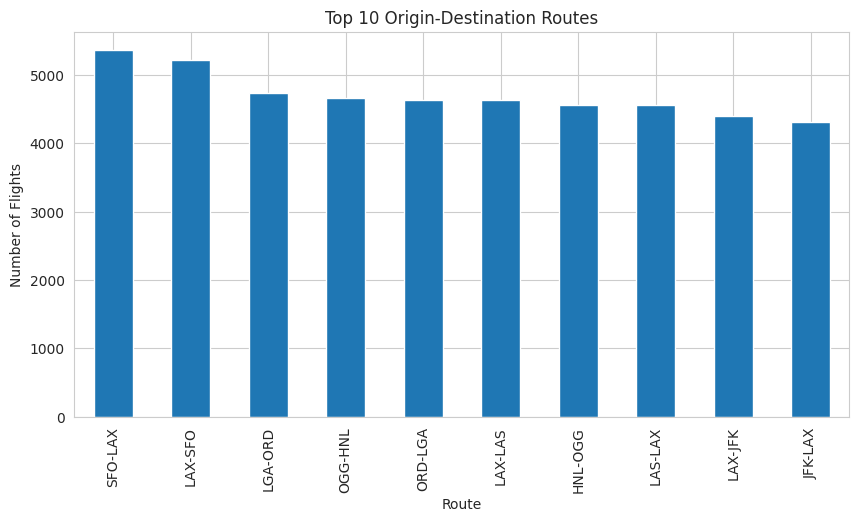

In [ ]:
top_routes = df['ROUTE'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_routes.plot(kind='bar')

plt.title("Top 10 Origin-Destination Routes")
plt.xlabel("Route")
plt.ylabel("Number of Flights")

plt.show()

**🔹 Step 2: Routes with Highest Delay**

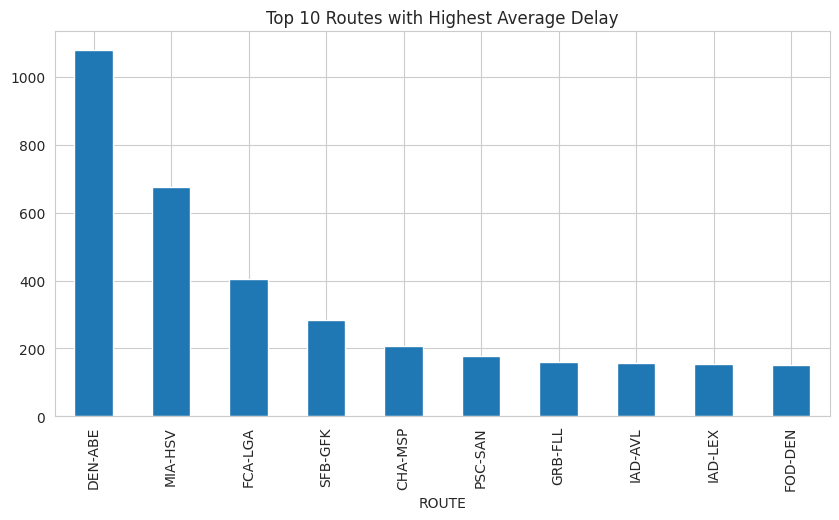

In [ ]:
route_delay = df.groupby('ROUTE')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
route_delay.plot(kind='bar')

plt.title("Top 10 Routes with Highest Average Delay")
plt.show()

**🔹 Step 3: Busiest Airports**

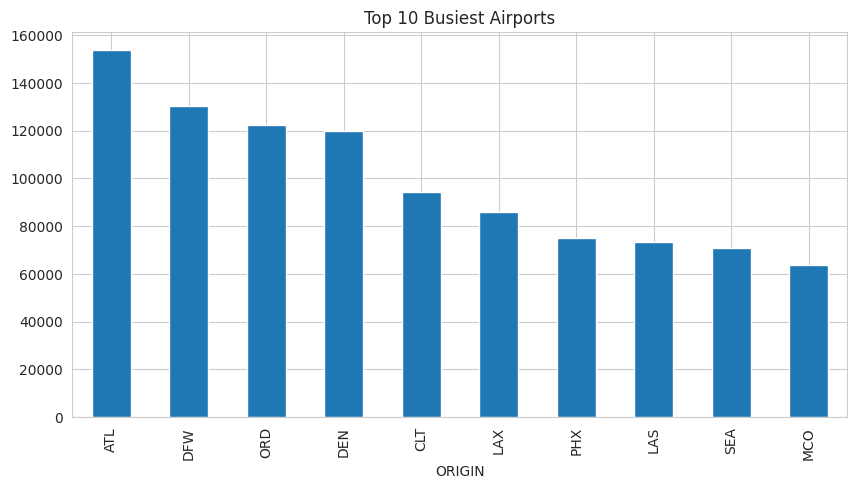

In [ ]:
top_airports = df['ORIGIN'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_airports.plot(kind='bar')

plt.title("Top 10 Busiest Airports")
plt.show()

**🔹 Step 4: Airport Delay Analysis**

/tmp/ipykernel_12132/1531880186.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airport_delay = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)


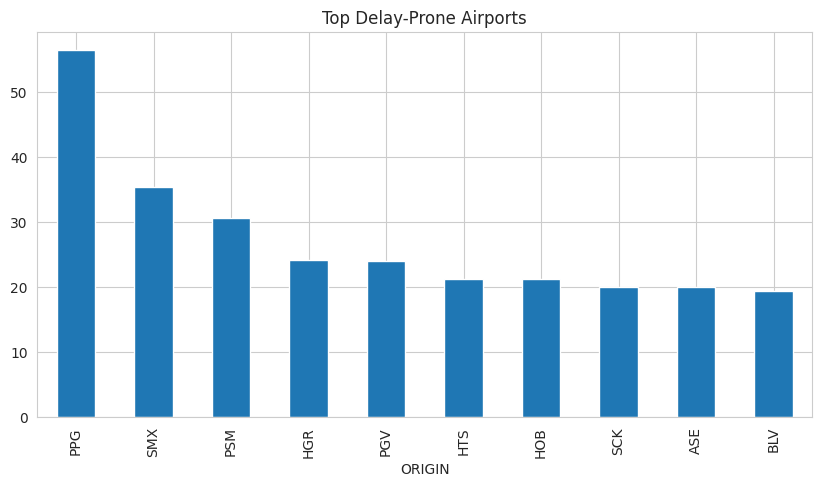

In [ ]:
airport_delay = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
airport_delay.plot(kind='bar')

plt.title("Top Delay-Prone Airports")
plt.show()

**🔹 Step 5: Route Heatmap**

/tmp/ipykernel_12132/2862856769.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='ARR_DELAY', index='ORIGIN', columns='DEST', aggfunc='mean')


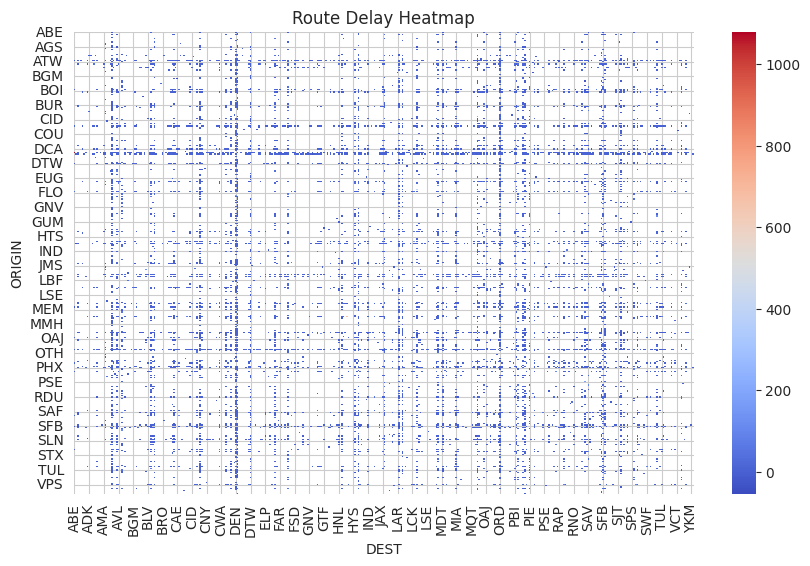

In [ ]:
pivot = df.pivot_table(values='ARR_DELAY', index='ORIGIN', columns='DEST', aggfunc='mean')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='coolwarm')

plt.title("Route Delay Heatmap")
plt.show()

**🔹 Step 6:  Airport Map 🌍**

In [ ]:
import plotly.express as px

airport_counts = df['ORIGIN'].value_counts().head(20).reset_index()
airport_counts.columns = ['AIRPORT', 'FLIGHTS']

fig = px.bar(airport_counts, x='AIRPORT', y='FLIGHTS',
             title="Top Airports by Traffic")

fig.show()

**🚀 WEEK 6 – Seasonal & Cancellation Analysis**

**🔹 Step 1: Monthly Cancellation Trend**

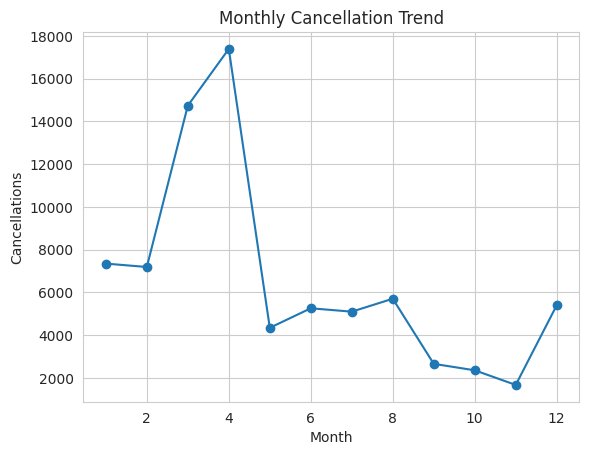

In [ ]:
cancel_month = df.groupby('MONTH')['CANCELLED'].sum()

plt.figure()
cancel_month.plot(kind='line', marker='o')

plt.title("Monthly Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Cancellations")

plt.show()

**🔹 Step 2: Cancellation Rate**

In [ ]:
cancel_rate = df['CANCELLED'].value_counts(normalize=True) * 100
cancel_rate

,proportion
CANCELLED,
0.0,97.362
1.0,2.638


**🔹 Step 3: Cancellation Reasons**

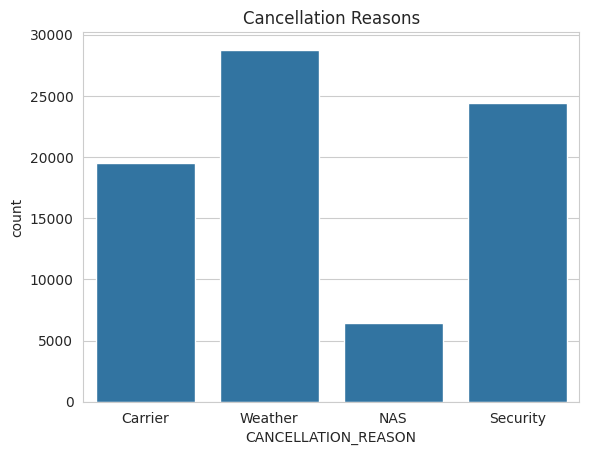

In [ ]:
sns.countplot(data=df, x='CANCELLATION_REASON')

plt.title("Cancellation Reasons")
plt.show()

**🔹 Step 4: Cancellation by Month & Reason**

/tmp/ipykernel_12132/123535688.py:1: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



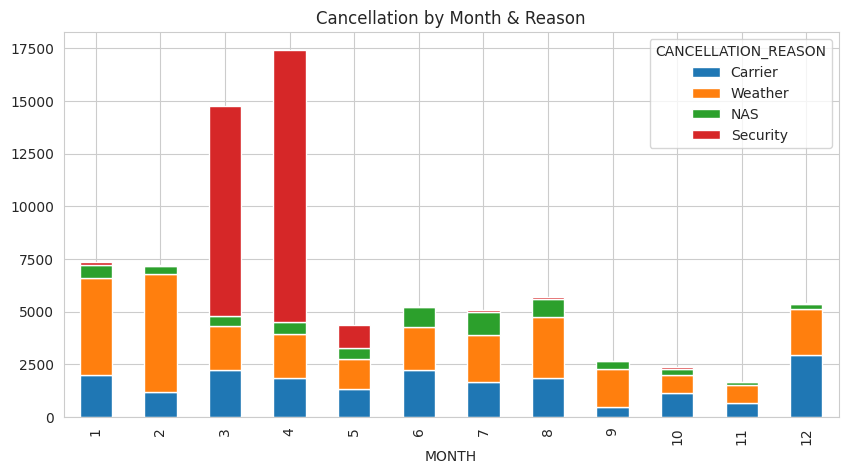

In [ ]:
pivot_cancel = df.pivot_table(
    values='CANCELLED',
    index='MONTH',
    columns='CANCELLATION_REASON',
    aggfunc='sum'
)

pivot_cancel.plot(kind='bar', stacked=True, figsize=(10,5))

plt.title("Cancellation by Month & Reason")
plt.show()

**🔹 Step 5: Seasonal Delay Trend**

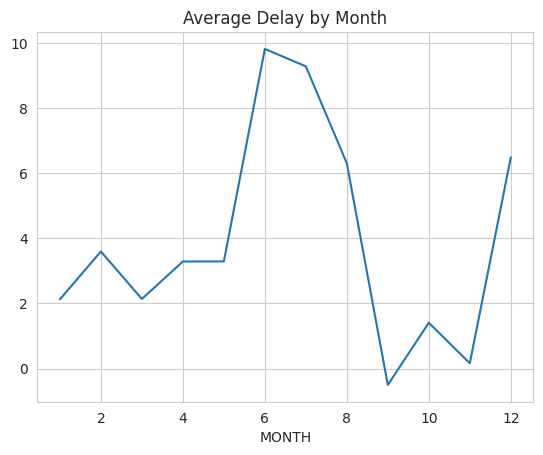

In [ ]:
monthly_delay = df.groupby('MONTH')['ARR_DELAY'].mean()

monthly_delay.plot(kind='line')

plt.title("Average Delay by Month")
plt.show()